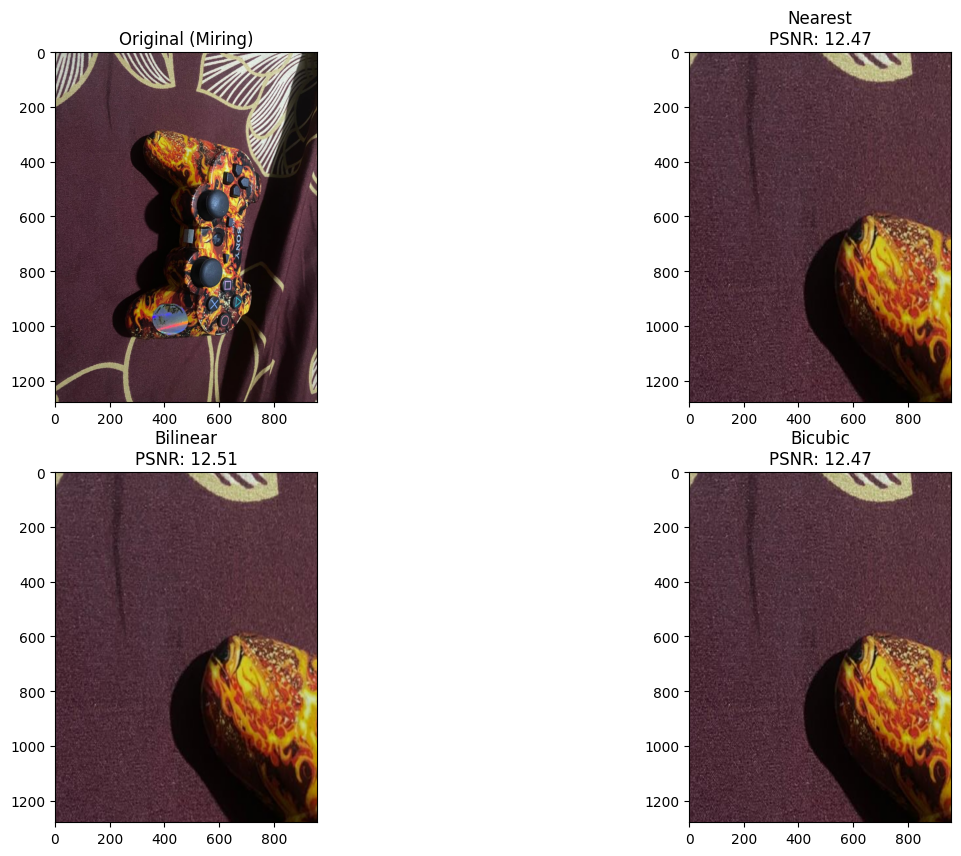

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time

# 1. Load Gambar (Ganti nama file sesuai yang Anda upload di Colab)
# Misal: img_ref adalah foto lurus, img_target adalah foto miring
img_ref = cv2.imread('FOTO LURUS.jpeg')
img_target = cv2.imread('FOTO MIRING.jpeg')

# Ubah ke RGB untuk plotting
img_ref = cv2.cvtColor(img_ref, cv2.COLOR_BGR2RGB)
img_target = cv2.cvtColor(img_target, cv2.COLOR_BGR2RGB)

# 2. Definisi Titik (Sesuaikan dengan koordinat pada gambar Anda)
# Anda perlu mencari 4 titik pojok kontroler/area tertentu
rows, cols, ch = img_ref.shape
pts_src = np.float32([[100, 100], [500, 100], [100, 500], [500, 500]]) # Contoh titik miring
pts_dst = np.float32([[0, 0], [cols, 0], [0, rows], [cols, rows]])    # Target lurus

# 3. Transformasi Perspektif
M_persp = cv2.getPerspectiveTransform(pts_src, pts_dst)

# 4. Pengujian 3 Metode Interpolasi & Waktu Komputasi
methods = [
    ("Nearest", cv2.INTER_NEAREST),
    ("Bilinear", cv2.INTER_LINEAR),
    ("Bicubic", cv2.INTER_CUBIC)
]

results = {}

for name, flag in methods:
    start_time = time.time()
    res = cv2.warpPerspective(img_target, M_persp, (cols, rows), flags=flag)
    end_time = time.time()

    # Hitung MSE & PSNR (Asumsi res dibandingkan dengan img_ref)
    # Pastikan ukuran img_ref dan res sama
    res_resized = cv2.resize(res, (img_ref.shape[1], img_ref.shape[0]))
    mse = np.mean((img_ref - res_resized) ** 2)
    psnr = cv2.PSNR(img_ref, res_resized)

    results[name] = {'img': res_resized, 'mse': mse, 'psnr': psnr, 'time': end_time - start_time}

# 5. Visualisasi Hasil
plt.figure(figsize=(15, 10))
plt.subplot(2, 2, 1), plt.imshow(img_target), plt.title('Original (Miring)')
plt.subplot(2, 2, 2), plt.imshow(results['Nearest']['img']), plt.title(f'Nearest\nPSNR: {results["Nearest"]["psnr"]:.2f}')
plt.subplot(2, 2, 3), plt.imshow(results['Bilinear']['img']), plt.title(f'Bilinear\nPSNR: {results["Bilinear"]["psnr"]:.2f}')
plt.subplot(2, 2, 4), plt.imshow(results['Bicubic']['img']), plt.title(f'Bicubic\nPSNR: {results["Bicubic"]["psnr"]:.2f}')
plt.show()